In [10]:
import sys
print(sys.executable)

/usr/local/anaconda3.2024/bin/python


In [11]:
from transformers import BertTokenizerFast, BertModel
import spacy
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import torch
import os

In [12]:
from data import *
from model import *
from utilsv2 import *


In [4]:
os.environ["TOKENIZERS_PARALLELISM"] = "true"

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Khởi tạo tokenizer và model BERT
tokenizer_bert = BertTokenizerFast.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased")


# Thêm token đặc biệt nếu chưa có
special_tokens = {"additional_special_tokens": ["[E1]", "[/E1]", "[E2]", "[/E2]"]}
num_added_toks = tokenizer_bert.add_special_tokens(special_tokens)
bert.resize_token_embeddings(len(tokenizer_bert))  # Resize embedding BERT


# Tokenizer và DataLoader
spacy_nlp = spacy.load('en_core_web_sm')
spacy_nlp.tokenizer = create_custom_tokenizer(spacy_nlp, special_tokens['additional_special_tokens'])

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [6]:
data_source = "/data/ddao/TRE/data/raw_data/TDDiscourse/TDDAutoProcessed/"
data_train_path = data_source + "train.csv"
data_valid_path = data_source + "dev.csv"
data_test_path = data_source + "test.csv"

train_df = pd.read_csv(data_train_path)
valid_df = pd.read_csv(data_valid_path)
test_df = pd.read_csv(data_test_path)

# Mã hóa nhãn
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])
valid_df['label_encoded'] = label_encoder.transform(valid_df['label'])
test_df['label_encoded'] = label_encoder.transform(test_df['label'])


label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Label Mapping: {label_mapping}")
relations = list(label_mapping.keys())

print("train_df:", train_df.shape)
print("valid_df:", valid_df.shape)
print("test_df:", test_df.shape)


Label Mapping: {'a': 0, 'b': 1, 'i': 2, 'ii': 3, 's': 4}
train_df: (32467, 12)
valid_df: (1435, 12)
test_df: (4258, 12)


In [7]:
print("Create dataloader:")
batch_size = 128
window_size = 128
MAX_LENGTH = 256
shuffle=False
print("batch_size: ", batch_size)
print("window_size: ", window_size)
print("MAX_LENGTH: ", MAX_LENGTH)

Create dataloader:
batch_size:  128
window_size:  128
MAX_LENGTH:  256


In [8]:
# --- Thống kê số lượng quan hệ trong từng tập ---
def count_relations(df, name="Dataset"):
    counts = df['label'].value_counts().sort_index()
    percents = (counts / len(df) * 100).round(2)
    stats_df = pd.DataFrame({
        'Relation': counts.index,
        f'{name} Count': counts.values,
        f'{name} %': percents.values
    })
    return stats_df

# Gộp kết quả ba tập thành một bảng duy nhất
train_stats = count_relations(train_df, "Train")
valid_stats = count_relations(valid_df, "Valid")
test_stats  = count_relations(test_df, "Test")

# Gộp tất cả vào một bảng chung (theo cột Relation)
summary_df = train_stats.merge(valid_stats, on="Relation", how="outer") \
                        .merge(test_stats, on="Relation", how="outer") \
                        .fillna(0)

# Thêm tổng cộng cho từng loại quan hệ
summary_df["Total Count"] = summary_df["Train Count"] + summary_df["Valid Count"] + summary_df["Test Count"]
summary_df["Total %"] = (summary_df["Total Count"] / summary_df["Total Count"].sum() * 100).round(2)

print("\n📊 Relation Statistics (MATRES):\n")
print(summary_df.to_string(index=False))


📊 Relation Statistics (MATRES):

Relation  Train Count  Train %  Valid Count  Valid %  Test Count  Test %  Total Count  Total %
       a        11047    34.03          440    30.66        1190   27.95        12677    33.22
       b         9864    30.38          327    22.79        1377   32.34        11568    30.31
       i         3272    10.08           66     4.60         487   11.44         3825    10.02
      ii         3769    11.61           98     6.83         515   12.09         4382    11.48
       s         4515    13.91          504    35.12         689   16.18         5708    14.96


In [9]:
# train_dataloader = create_dataloader(train_df, spacy_nlp, tokenizer_bert, special_tokens, batch_size, window_size, MAX_LENGTH, shuffle, is_TDD=True)
# validation_dataloader = create_dataloader(valid_df, spacy_nlp, tokenizer_bert, special_tokens, batch_size, window_size, MAX_LENGTH, shuffle, is_TDD=True)
# test_dataloader = create_dataloader(test_df, spacy_nlp, tokenizer_bert, special_tokens, batch_size, window_size, MAX_LENGTH, shuffle, is_TDD=True)

In [10]:
train_dataloader_path =  f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDAuto/train_dataloader_ws_{window_size}.pt"
validation_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDAuto/validation_dataloader_ws_{window_size}.pt"
test_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDAuto/test_dataloader_ws_{window_size}.pt"

In [11]:
# torch.save(train_dataloader, train_dataloader_path)
# torch.save(validation_dataloader, validation_dataloader_path)
# torch.save(test_dataloader, test_dataloader_path)

In [12]:
train_dataloader = torch.load(train_dataloader_path)
validation_dataloader = torch.load(validation_dataloader_path)
test_dataloader = torch.load(test_dataloader_path)

In [13]:
# ============================================================
# Hyperparameters
# ============================================================
hidden_ffn_dim   = 512
num_heads        = 8
num_layers       = 1
dropout          = 0.3
num_classes      = len(label_encoder.classes_)

num_epochs       = 30
eval_step        = 1
LEARNING_RATE    = 1e-5

top_k            = 10

print(f"hidden_ffn_dim: {hidden_ffn_dim}")
print(f"num_layers: {num_layers}")
print(f"num_heads: {num_heads}")
print(f"top_k: {top_k}")

# ============================================================
# Save path
# ============================================================

save_path = (
    f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDAuto/"
    f"FTBERT_TDDAuto_MHA_{num_layers}_FFN_{hidden_ffn_dim}_TOP_{top_k}.pth"
)
print('Model will save at:', save_path)

hidden_ffn_dim: 512
num_layers: 1
num_heads: 8
top_k: 10
Model will save at: /data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDAuto/FTBERT_TDDAuto_MHA_1_FFN_512_TOP_10.pth


In [14]:
print("\nCreate model:")
model = TemporalRelationModelV2(
    bert=bert,
    tokenizer=tokenizer_bert,
    hidden_ffn_dim=hidden_ffn_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout,
    num_classes=num_classes,
    device=device
).to(device)

print("Device:", device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print("--" * 20)


Create model:
Device: cuda
----------------------------------------


/home/prof/ddao/.local/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [15]:
# print("\nStart Training...")
# losses = train_model(
#     model=model,
#     top_k=top_k,
#     train_dataloader=train_dataloader,
#     validation_dataloader=validation_dataloader,
#     optimizer=optimizer,
#     criterion=criterion,
#     device=device,
#     num_epochs=num_epochs,
#     save_path=save_path,
#     eval_step=eval_step,
#     max_grad_norm=1.0,      # clip grad
#     lambda_aux=1.0,         # weight cho aux loss (0 nếu không dùng)
#     is_TDD=True
# )

# Evaluate

In [16]:
print("Load pretrained model:")
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']
print(f"Model saved at epoch {epoch}, loss = {loss:.4f}")

Load pretrained model:
Model saved at epoch 28, loss = 0.0048


In [17]:
metrics_by_topk = grid_search(test_dataloader,
                                model,
                                20,
                                device,
                                is_TDD=True)

Evaluating: 100%|██████████| 34/34 [00:19<00:00,  1.78it/s]


Evaluation finished in 19.12s.
[TDD] F1=0.6933, P=0.6933, R=0.6933
top_K: 0 - F1: 0.6933 | Precision: 0.6933 | Recall: 0.6933



Evaluating: 100%|██████████| 34/34 [00:18<00:00,  1.83it/s]


Evaluation finished in 18.55s.
[TDD] F1=0.7090, P=0.7090, R=0.7090
top_K: 1 - F1: 0.7090 | Precision: 0.7090 | Recall: 0.7090



Evaluating: 100%|██████████| 34/34 [00:18<00:00,  1.82it/s]


...

Evaluation finished in 19.11s.
[TDD] F1=0.7053, P=0.7053, R=0.7053
top_K: 18 - F1: 0.7053 | Precision: 0.7053 | Recall: 0.7053



Evaluating: 100%|██████████| 34/34 [00:19<00:00,  1.78it/s]


Evaluation finished in 19.05s.
[TDD] F1=0.7039, P=0.7039, R=0.7039
top_K: 19 - F1: 0.7039 | Precision: 0.7039 | Recall: 0.7039



Evaluating: 100%|██████████| 34/34 [00:19<00:00,  1.79it/s]

Evaluation finished in 19.04s.
[TDD] F1=0.7041, P=0.7041, R=0.7041
top_K: 20 - F1: 0.7041 | Precision: 0.7041 | Recall: 0.7041



In [18]:
# Tạo DataFrame
df = pd.DataFrame(metrics_by_topk, columns=["top_k", "F1", "Precision", "Recall"])
df.to_csv("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDAuto/metrics_by_topk.csv", index=False, encoding='utf-8-sig')

In [19]:
df = pd.read_csv("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDAuto/metrics_by_topk.csv", encoding='utf-8-sig')

In [20]:
# Lấy hàng có F1 cao nhất
best_row = df.loc[df['F1'].idxmax()]

best_k = int(best_row['top_k'])
best_f1 = best_row['F1']
best_p = best_row['Precision']
best_r = best_row['Recall']

print(f"✅ Top-K tốt nhất: {best_k}")
print(f"F1 = {best_f1:.4f} | Precision = {best_p:.4f} | Recall = {best_r:.4f}")


✅ Top-K tốt nhất: 1
F1 = 0.7090 | Precision = 0.7090 | Recall = 0.7090


In [21]:
cm, f1, p, r, precisions, recalls, f1s, all_predictions, all_labels, logs = evaluate(test_dataloader,
                                                    model=model,
                                                    top_k=best_k,
                                                    device=device,
                                                    return_preds=True,
                                                    is_TDD=True,
                                                    return_topk_tokens=True,
                                                    return_logs=True
                                                    )

Evaluating: 100%|██████████| 34/34 [00:20<00:00,  1.63it/s]

Evaluation finished in 20.82s.
[TDD] F1=0.7090, P=0.7090, R=0.7090


In [ ]:
torch.cuda.empty_cache()

# Top-K Analysis

In [4]:
from analysis_topk import *

In [23]:
id2label = {v:k for k, v in label_mapping.items()}

In [24]:
# df_expanded = add_is_intra_batch(train_df, batch_size=64)
df_expanded = add_is_intra_batch(test_df, spacy_nlp, batch_size=64)

In [25]:
d4A = build_analysis_dataset(all_labels,
                             all_predictions,
                             logs,
                             id2label,
                             entity_pairs=df_expanded.values.tolist(),
                             vocab=spacy_nlp.vocab)  # giúp decode id → string)

In [26]:
# Write dictionary to JSON file
with open("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDAuto/data4analyze.json", "w") as json_file:
    json.dump(d4A, json_file, indent=4)

In [27]:
df_analysis = create_analysis_dataframe(d4A)

In [28]:
# df_analysis.to_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDAuto/train_D4A.json")
df_analysis.to_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDAuto/test_D4A.json")


In [13]:
# df_analysis = pd.read_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDAuto/train_D4A.json")
df_analysis = pd.read_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDAuto/test_D4A.json")

POS distribution per entity_type:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.081729  0.087130  0.022311  0.038751  0.040629  0.081729   
e2           0.100986  0.105918  0.018553  0.042743  0.027713  0.087600   
pair         0.086895  0.104039  0.019023  0.052607  0.022076  0.089713   

pos              INTJ      NOUN       NUM      PART      PRON     PROPN  \
entity_type                                                               
e1           0.000000  0.209488  0.029826  0.011977  0.035698  0.116956   
e2           0.000939  0.190700  0.026303  0.022546  0.039690  0.155237   
pair         0.000705  0.214185  0.024190  0.014326  0.041099  0.167215   

pos             PUNCT     SCONJ       SYM      VERB         X  
entity_type                                                    
e1           0.014091  0.014326  0.001879  0.211367  0.002114  
e2           0.017849 

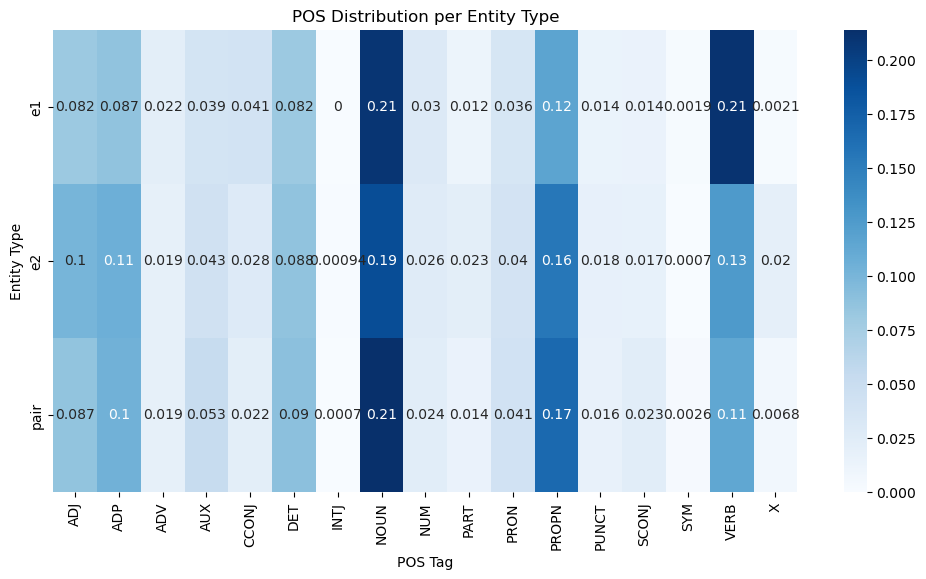

In [14]:
pos_distribution(df_analysis)

Dependency distribution per entity_type:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.028182  0.011038  0.002818  0.024190  0.025834  0.002114   
e2           0.032879  0.016674  0.002583  0.018318  0.027008  0.001644   
pair         0.019258  0.010568  0.002818  0.014561  0.031705  0.001879   

dep              amod     appos      attr       aux  ...     pcomp      pobj  \
entity_type                                          ...                       
e1           0.091827  0.003053  0.009394  0.034758  ...  0.009394  0.088774   
e2           0.098638  0.004932  0.004697  0.042039  ...  0.006106  0.094645   
pair         0.085721  0.008924  0.003758  0.043448  ...  0.003758  0.103335   

dep              poss   preconj      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.007515  0.000000 

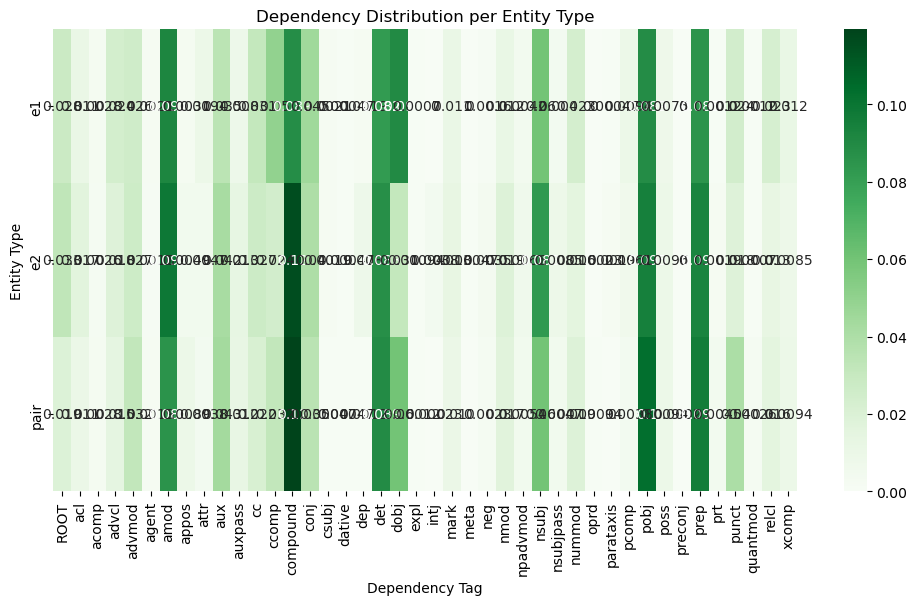

In [15]:
dep_distribution(df_analysis)

Morphology distribution per entity_type:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.155942                              0.036167   
e2           0.190935                              0.023485   
pair         0.182010                              0.019023   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.035463   
e2                                       0.023720   
pair                                     0.017614   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000470        
e2                                                    0.001409        
pair                                                  0.000705        

morph        Case=Acc

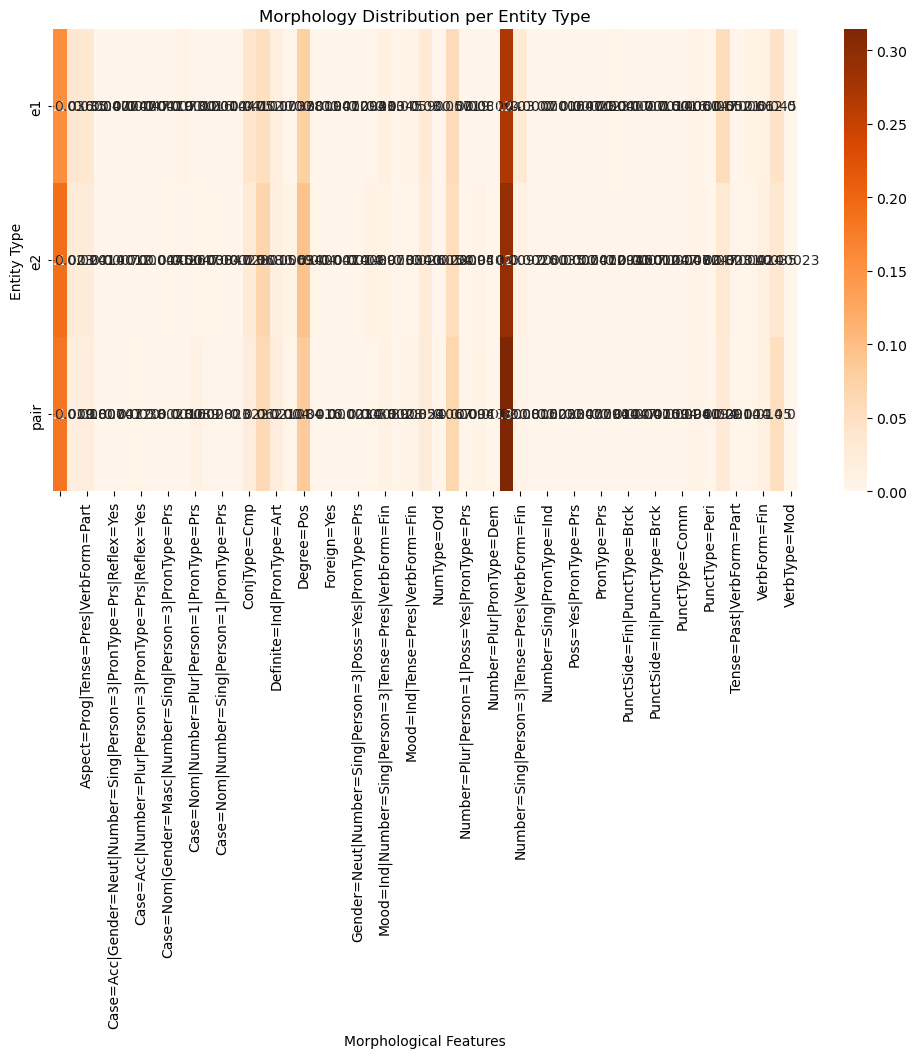

In [16]:
morph_distribution(df_analysis)

Số cặp với prediction đúng: 9057

=== Relation: a ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.104492  0.109375  0.027344  0.043945  0.031250  0.090820   
e2           0.112305  0.106445  0.019531  0.041016  0.021484  0.092773   
pair         0.068359  0.103516  0.012695  0.061523  0.030273  0.068359   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.168945  0.049805  0.012695  0.029297  0.120117  0.022461   
e2           0.198242  0.012695  0.023438  0.037109  0.171875  0.025391   
pair         0.206055  0.029297  0.014648  0.051758  0.175781  0.015625   

pos             SCONJ       SYM      VERB         X  
entity_type                                          
e1           0.014648  0.000977  0.171875  0.001953  
e2           0

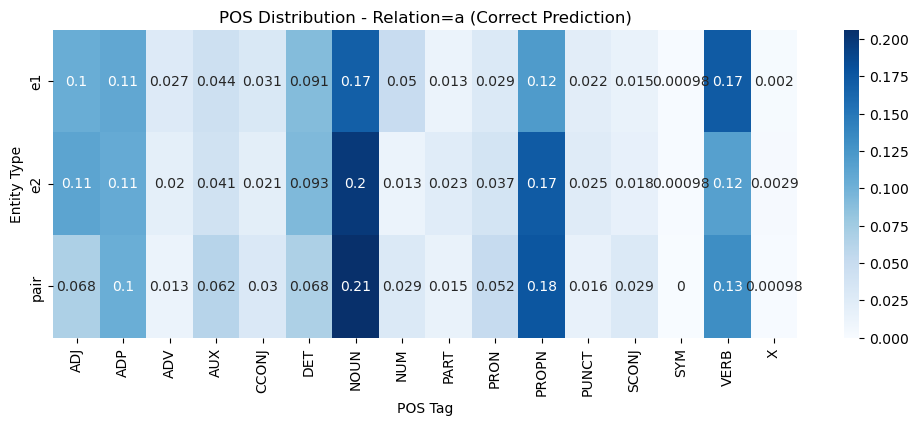

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.022461  0.013672  0.002930  0.024414  0.032227  0.000977   
e2           0.016602  0.017578  0.003906  0.009766  0.023438  0.003906   
pair         0.023438  0.006836  0.002930  0.015625  0.036133  0.000000   

dep              amod     appos      attr       aux  ...      oprd     pcomp  \
entity_type                                          ...                       
e1           0.096680  0.001953  0.003906  0.038086  ...  0.000000  0.014648   
e2           0.119141  0.001953  0.002930  0.048828  ...  0.000977  0.008789   
pair         0.072266  0.001953  0.005859  0.041992  ...  0.000977  0.001953   

dep              pobj      poss      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.103516  0.006836  0.105469  0.000

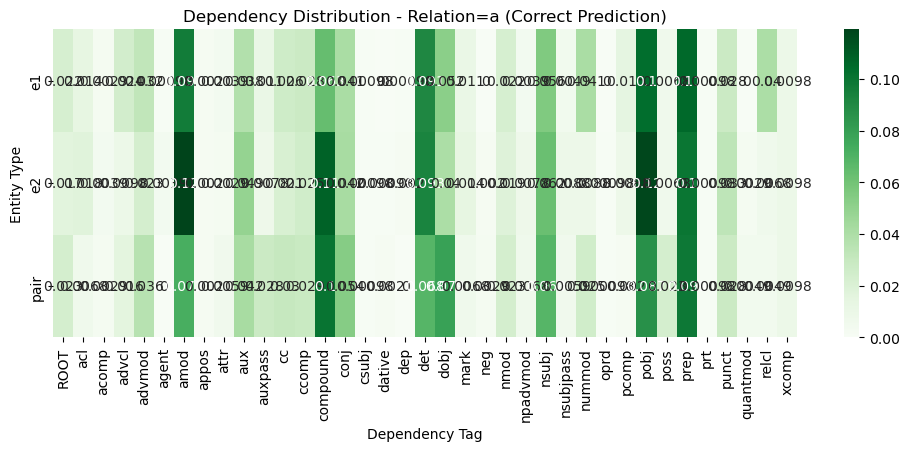

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.179688                              0.022461   
e2           0.171875                              0.032227   
pair         0.166992                              0.017578   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.042969   
e2                                       0.018555   
pair                                     0.012695   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000000        
e2                                                    0.005859        
pair                                                  0.000000        

morph        Case=Acc|Gender=Neut|Num

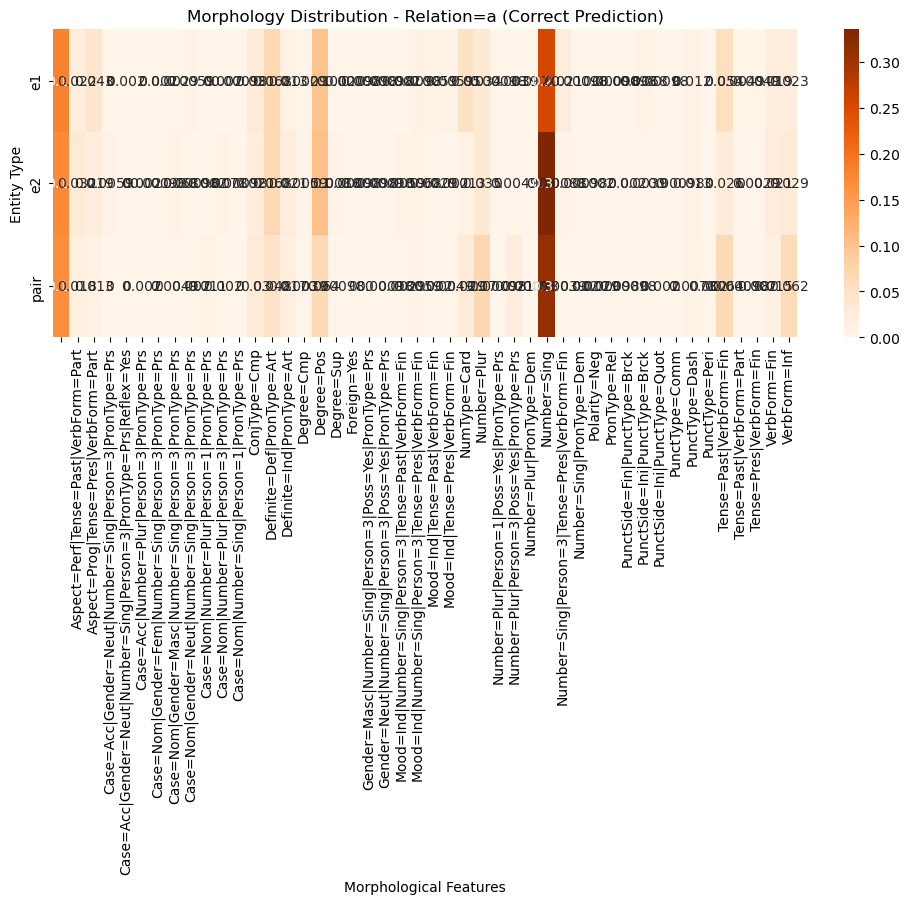


=== Relation: b ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.065943  0.081803  0.028381  0.040902  0.050083  0.067613   
e2           0.076795  0.098497  0.023372  0.046745  0.024207  0.086811   
pair         0.094324  0.100167  0.022538  0.053422  0.013356  0.087646   

pos              INTJ      NOUN       NUM      PART      PRON     PROPN  \
entity_type                                                               
e1           0.000000  0.222037  0.029215  0.015025  0.040902  0.157763   
e2           0.002504  0.161102  0.047579  0.016694  0.047579  0.161102   
pair         0.001669  0.222871  0.020868  0.016694  0.039232  0.147746   

pos             PUNCT     SCONJ       SYM      VERB         X  
entity_type                                                    
e1           0.009182  0.012521  0.001669  0.174457  0.002504  
e2           0.01

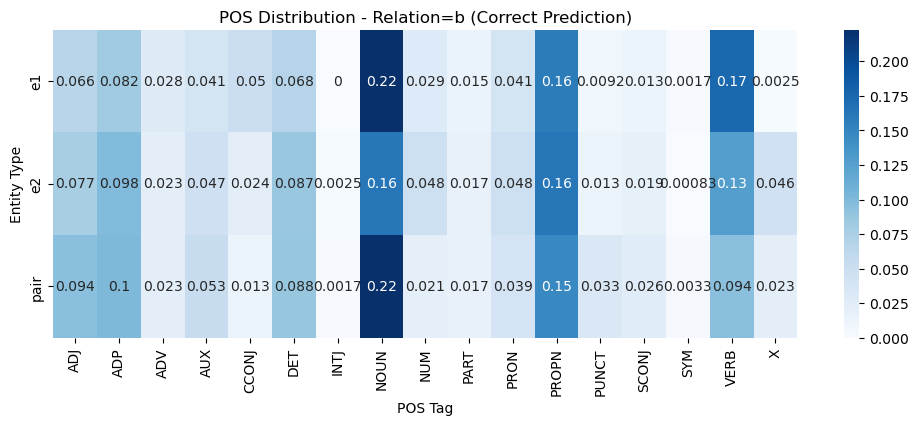

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.017529  0.008347  0.001669  0.026711  0.030050  0.003339   
e2           0.062604  0.007513  0.000835  0.028381  0.031720  0.002504   
pair         0.020033  0.016694  0.002504  0.010017  0.035893  0.004174   

dep              amod     appos      attr       aux  ...  parataxis     pcomp  \
entity_type                                          ...                        
e1           0.072621  0.005843  0.003339  0.039232  ...   0.000000  0.005008   
e2           0.068447  0.006678  0.001669  0.041736  ...   0.001669  0.003339   
pair         0.090985  0.015025  0.001669  0.039232  ...   0.000000  0.001669   

dep              pobj      poss   preconj      prep       prt     punct  \
entity_type                                                               
e1           0.094324  0.005008  0.000000  

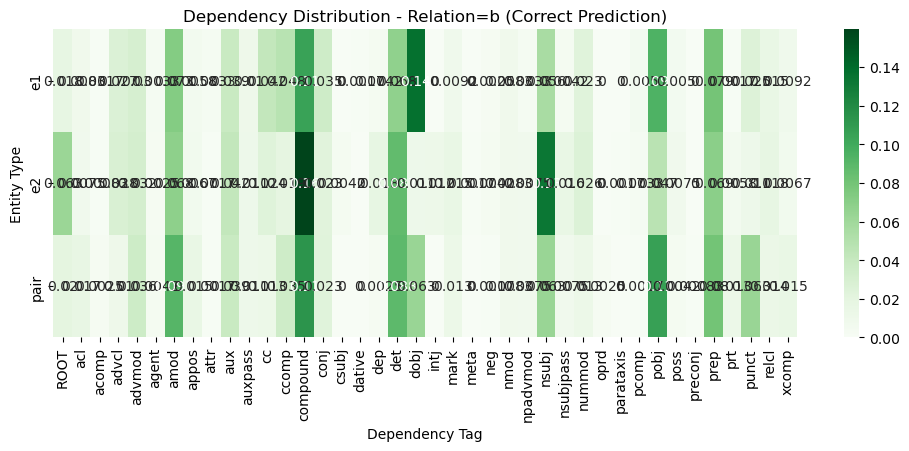

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.153589                              0.023372   
e2           0.214524                              0.015025   
pair         0.218698                              0.015860   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.021703   
e2                                       0.023372   
pair                                     0.016694   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.001669        
e2                                                    0.000000        
pair                                                  0.000000        

morph        Case=Acc|Gender=Neut|Num

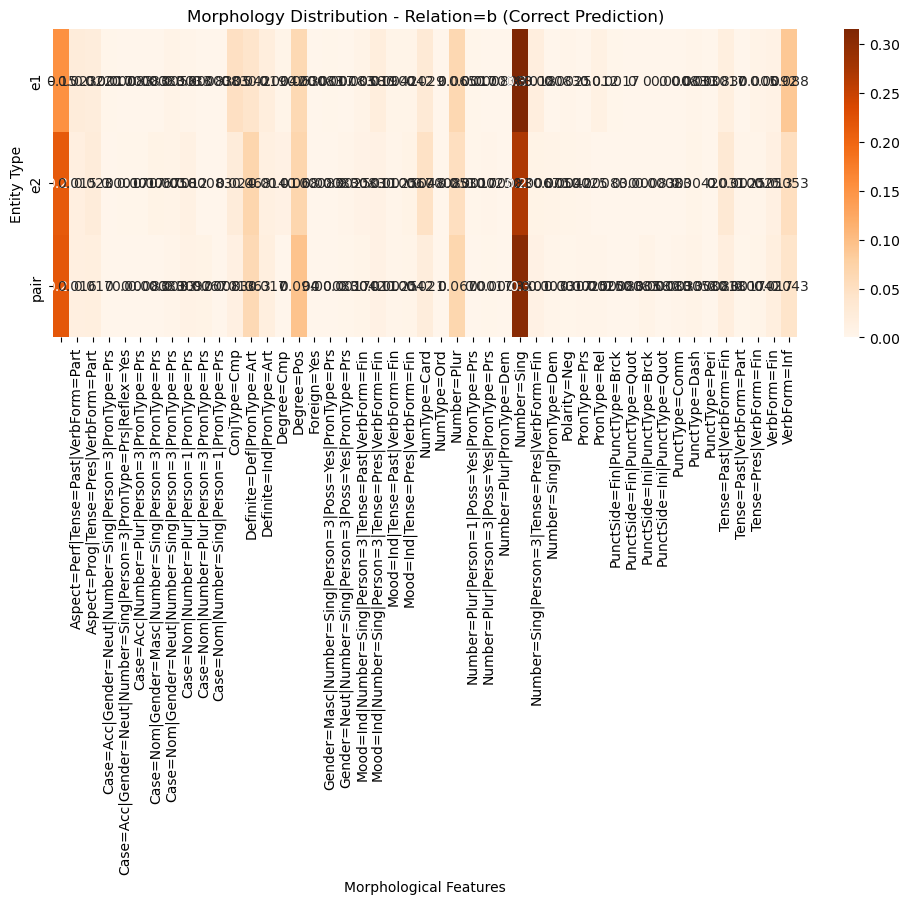


=== Relation: s ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.087671  0.054795  0.021918  0.021918  0.019178  0.049315   
e2           0.167123  0.136986  0.010959  0.032877  0.024658  0.087671   
pair         0.049315  0.063014  0.019178  0.038356  0.010959  0.131507   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.106849  0.010959  0.005479  0.019178  0.068493  0.013699   
e2           0.232877  0.008219  0.024658  0.019178  0.120548  0.013699   
pair         0.252055  0.027397  0.016438  0.027397  0.205479  0.005479   

pos             SCONJ      SYM      VERB         X  
entity_type                                         
e1           0.024658  0.00000  0.495890  0.000000  
e2           0.010959  0.00000  0.104110  0.005479

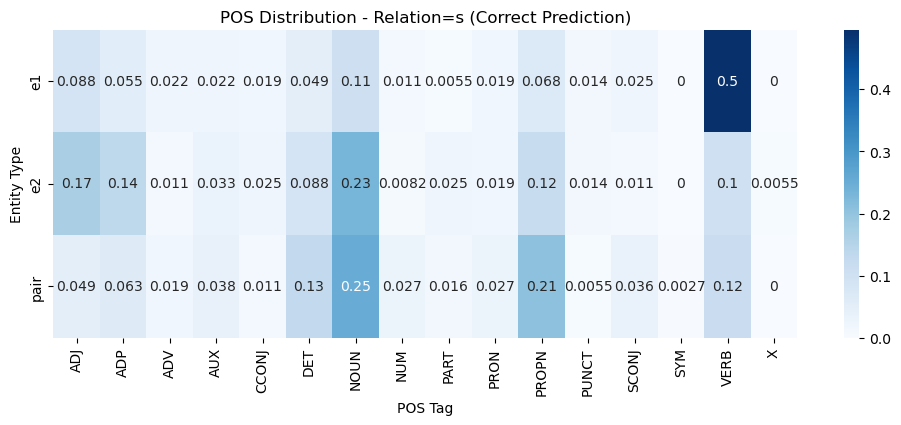

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod    agent  \
entity_type                                                              
e1           0.090411  0.032877  0.008219  0.046575  0.032877  0.00000   
e2           0.013699  0.008219  0.000000  0.008219  0.019178  0.00000   
pair         0.024658  0.008219  0.002740  0.043836  0.046575  0.00274   

dep              amod     appos     attr       aux  ...  nsubjpass    nummod  \
entity_type                                         ...                        
e1           0.131507  0.008219  0.00274  0.024658  ...    0.00000  0.008219   
e2           0.169863  0.010959  0.00000  0.032877  ...    0.00274  0.002740   
pair         0.054795  0.002740  0.00000  0.032877  ...    0.00274  0.021918   

dep             pcomp      pobj      poss      prep     punct  quantmod  \
entity_type                                                               
e1           0.000000  0.032877  0.010959  0.068493  

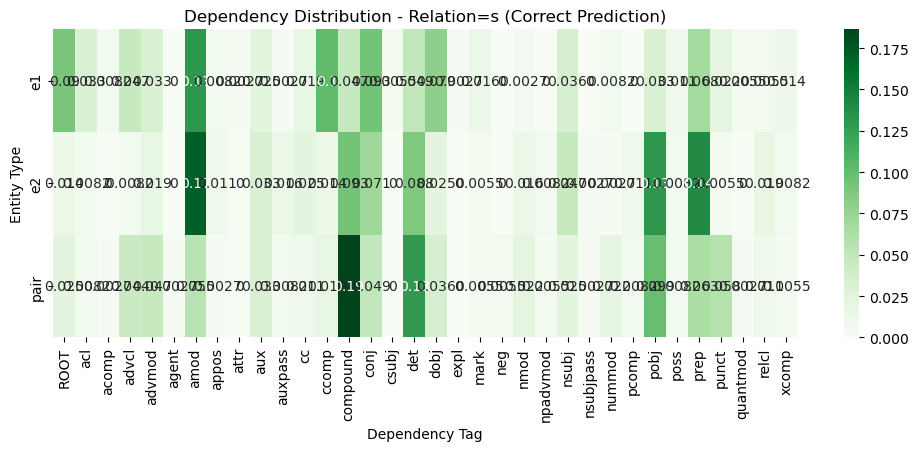

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.115068                              0.104110   
e2           0.186301                              0.005479   
pair         0.134247                              0.060274   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.057534   
e2                                       0.019178   
pair                                     0.016438   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000000        
e2                                                    0.000000        
pair                                                  0.005479        

morph        Case=Acc|Gender=Neut|Num

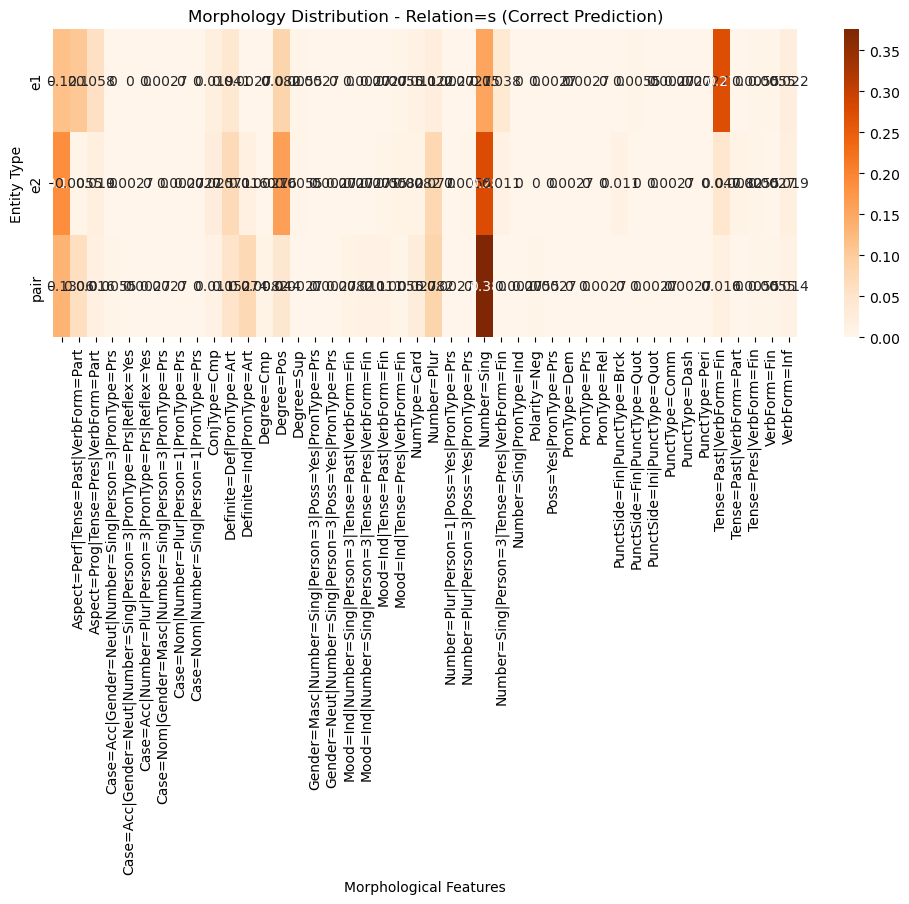


=== Relation: ii ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.090476  0.061905  0.033333  0.061905  0.047619  0.090476   
e2           0.109524  0.080952  0.014286  0.071429  0.071429  0.095238   
pair         0.085714  0.114286  0.014286  0.042857  0.038095  0.104762   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.238095  0.014286  0.009524  0.042857  0.104762  0.000000   
e2           0.204762  0.028571  0.019048  0.033333  0.147619  0.028571   
pair         0.228571  0.009524  0.004762  0.047619  0.214286  0.000000   

pos             SCONJ      VERB         X  
entity_type                                
e1           0.009524  0.190476  0.004762  
e2           0.009524  0.085714  0.000000  
pair         0.009524  0.085714 

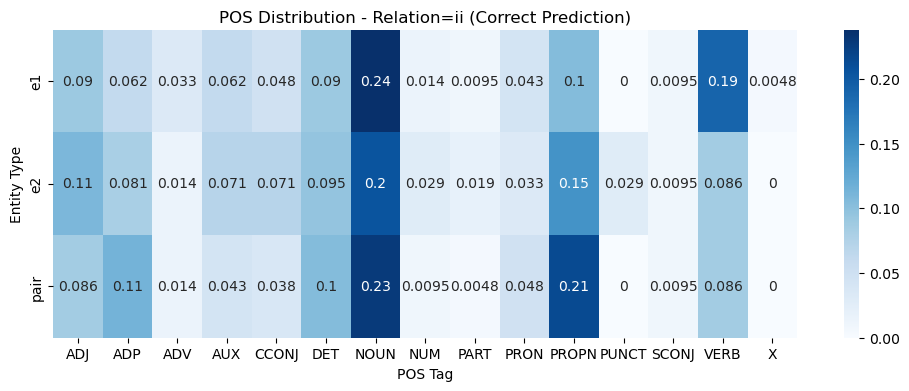

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.009524  0.000000  0.000000  0.019048  0.028571  0.004762   
e2           0.004762  0.000000  0.004762  0.019048  0.023810  0.000000   
pair         0.019048  0.004762  0.000000  0.019048  0.019048  0.004762   

dep              amod     appos      attr       aux  ...     nsubj  nsubjpass  \
entity_type                                          ...                        
e1           0.090476  0.004762  0.000000  0.038095  ...  0.038095   0.000000   
e2           0.095238  0.004762  0.023810  0.033333  ...  0.090476   0.000000   
pair         0.085714  0.009524  0.004762  0.038095  ...  0.033333   0.009524   

dep            nummod     pcomp      pobj      poss      prep     punct  \
entity_type                                                               
e1           0.014286  0.004762  0.104762  

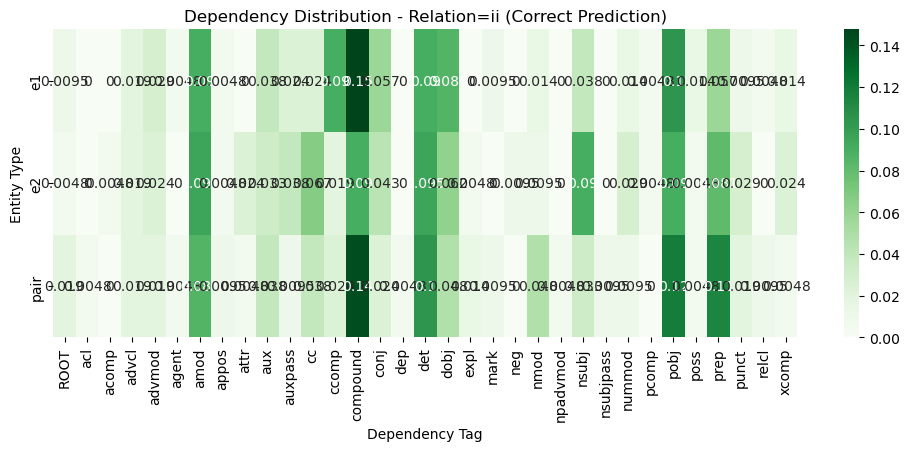

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.142857                              0.009524   
e2           0.138095                              0.009524   
pair         0.176190                              0.028571   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.057143   
e2                                       0.019048   
pair                                     0.014286   

morph        Case=Acc|Number=Plur|Person=3|PronType=Prs  \
entity_type                                               
e1                                             0.004762   
e2                                             0.004762   
pair                                           0.004762   

morph        Case=Nom|Gender=Masc|Number=Sing|Person=3|PronType=Prs  \
entity_type               

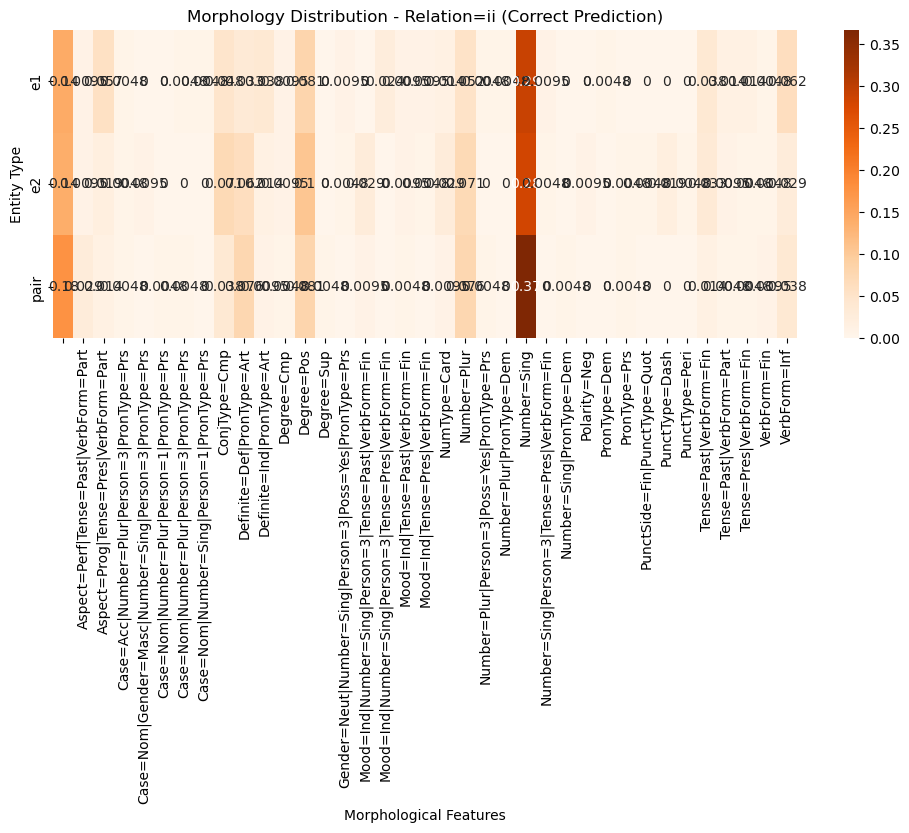


=== Relation: i ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.081081  0.121622  0.027027  0.018018  0.040541  0.090090   
e2           0.108108  0.112613  0.004505  0.027027  0.013514  0.108108   
pair         0.067568  0.144144  0.004505  0.076577  0.027027  0.067568   

pos              INTJ      NOUN       NUM      PART      PRON     PROPN  \
entity_type                                                               
e1           0.000000  0.274775  0.013514  0.013514  0.031532  0.103604   
e2           0.004505  0.229730  0.045045  0.036036  0.009009  0.112613   
pair         0.000000  0.211712  0.054054  0.009009  0.072072  0.121622   

pos             PUNCT     SCONJ       SYM      VERB         X  
entity_type                                                    
e1           0.009009  0.004505  0.013514  0.153153  0.004505  
e2           0.00

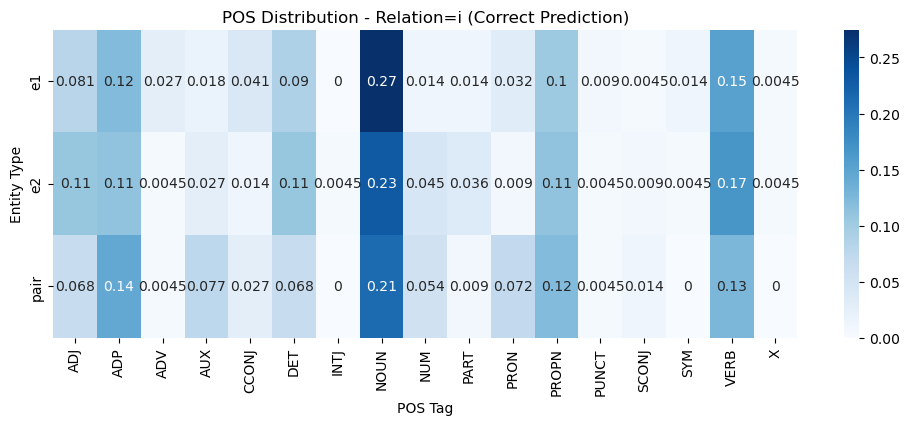

Dependency distribution:
dep              ROOT       acl     advcl    advmod      amod     appos  \
entity_type                                                               
e1           0.018018  0.009009  0.022523  0.022523  0.094595  0.000000   
e2           0.018018  0.027027  0.031532  0.013514  0.099099  0.009009   
pair         0.009009  0.013514  0.000000  0.018018  0.063063  0.031532   

dep              attr       aux   auxpass        cc  ...    nummod  parataxis  \
entity_type                                          ...                        
e1           0.004505  0.013514  0.000000  0.040541  ...  0.004505   0.000000   
e2           0.004505  0.031532  0.009009  0.013514  ...  0.031532   0.009009   
pair         0.004505  0.076577  0.004505  0.027027  ...  0.049550   0.000000   

dep             pcomp      pobj      poss      prep     punct  quantmod  \
entity_type                                                               
e1           0.000000  0.090090  0.004505  

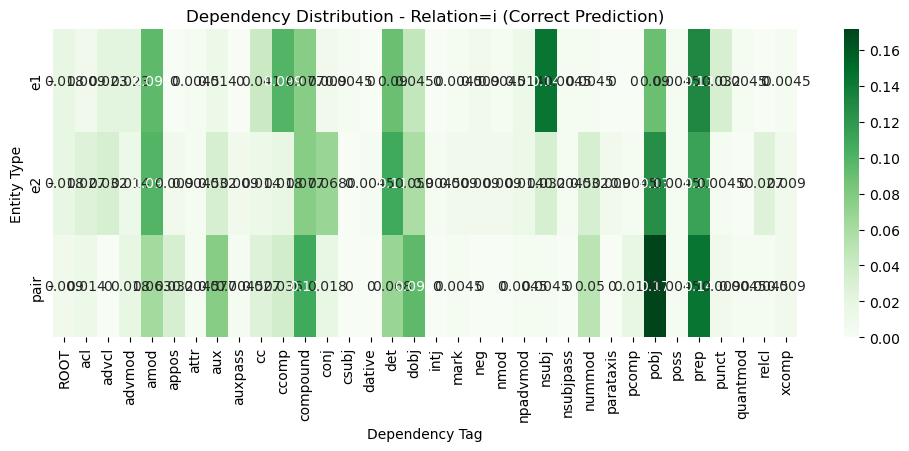

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.162162                              0.027027   
e2           0.166667                              0.027027   
pair         0.166667                              0.013514   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.013514   
e2                                       0.031532   
pair                                     0.031532   

morph        Case=Acc|Number=Plur|Person=3|PronType=Prs|Reflex=Yes  \
entity_type                                                          
e1                                                    0.000000       
e2                                                    0.000000       
pair                                                  0.067568       

morph        Case=Nom|Gender=Neut|Number=S

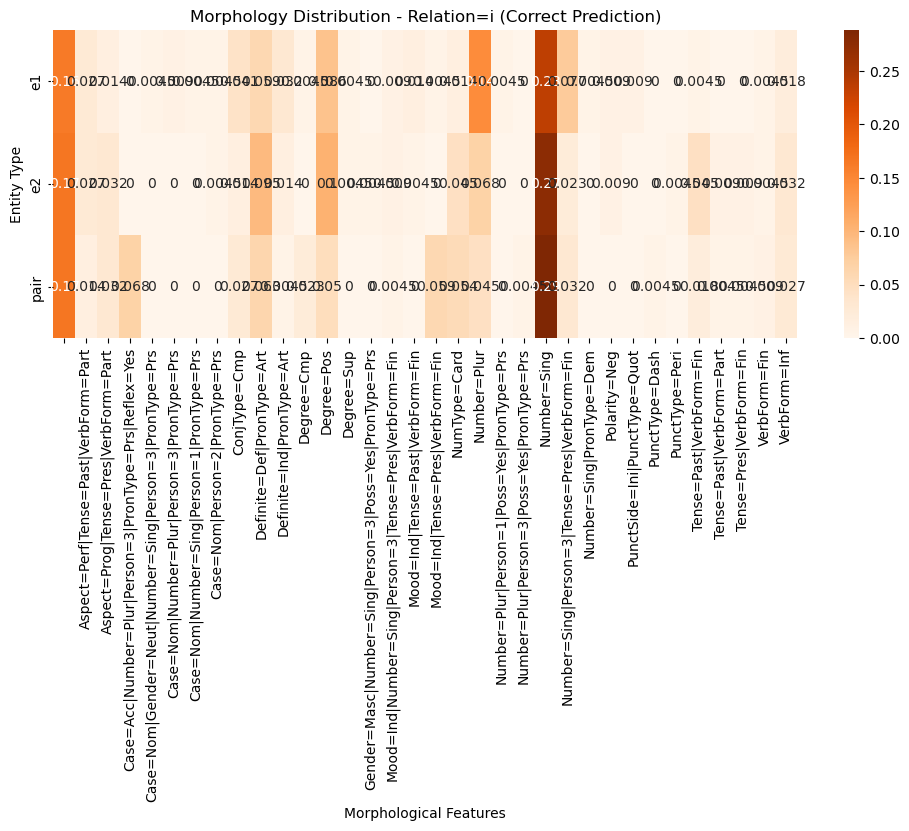

In [17]:
analyze_pos_dep_morph_by_relation(df_analysis)